In [7]:
!pip install yfinance


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [73]:
import yfinance as yf
import pandas as pd
from pathlib import Path


data_dir = Path("../data/capital_flows")
data_dir.mkdir(parents=True, exist_ok=True)


tickers = {
    "USDTRY=X": "turkey_usd_rate.csv",
    "USDARS=X": "argentina_usd_rate.csv",
}


for ticker, filename in tickers.items():
    print(f"Downloading {ticker}...")
    data = yf.download(ticker, start="2013-01-01", end="2025-01-01", progress=False)
    
    if data.empty:
        print(f"  No data for {ticker}")
    else:
        data.to_csv(data_dir / filename)
        print(f"  Saved {len(data)} rows to {filename}")

  Saved 3127 rows to turkey_usd_rate.csv
  Saved 3127 rows to argentina_usd_rate.csv


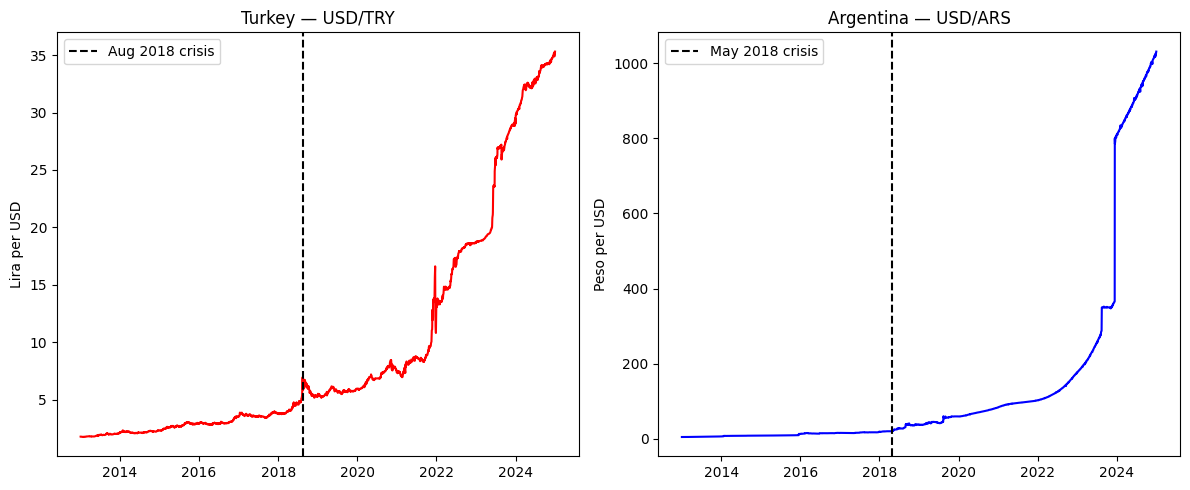

In [72]:
import matplotlib.pyplot as plt

turkey = pd.read_csv(data_dir / "turkey_usd_rate.csv", skiprows=2)
argentina = pd.read_csv(data_dir / "argentina_usd_rate.csv", skiprows=2)

for df in [turkey, argentina]:
    df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    df["Date"] = pd.to_datetime(df["Date"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(turkey["Date"], turkey["Close"], color="red")
axes[0].set_title("Turkey — USD/TRY")
axes[0].set_ylabel("Lira per USD")
axes[0].axvline(pd.Timestamp("2018-08-13"), color="black", linestyle="--", label="Aug 2018 crisis")
axes[0].legend()
axes[1].plot(argentina["Date"], argentina["Close"], color="blue")
axes[1].set_title("Argentina — USD/ARS")
axes[1].set_ylabel("Peso per USD")
axes[1].axvline(pd.Timestamp("2018-05-01"), color="black", linestyle="--", label="May 2018 crisis")
axes[1].legend()

plt.tight_layout()
plt.show()

In [74]:
for country_name, df in [("Turkey", turkey), ("Argentina", argentina)]:
    df["pct_change"] = df["Close"].pct_change() * 100
    worst_days = df[df["pct_change"] > 3].sort_values("pct_change", ascending=False)
    
    print(country_name)
    print(worst_days[["Date", "Close", "pct_change"]].head(5).to_string(index=False))

Turkey
      Date    Close  pct_change
2018-08-13  6.81780   22.798991
2021-11-24 12.81890   12.386353
2021-03-22  8.09539   10.589440
2021-12-30 12.64030    7.092872
2021-12-28 11.52105    6.606607
Argentina
      Date      Close  pct_change
2023-12-14 799.963501  118.287764
2015-12-18  13.299000   35.594768
2023-08-15 349.936096   21.762489
2019-08-13  54.578999   20.715274
2014-01-24   7.897400   13.980977


In [37]:
crisis_dates = {
    "Turkey": "2018-08-13",     
    "Argentina": "2018-05-01",   
}




In [20]:
import requests

url = "https://api.gdeltproject.org/api/v2/doc/doc"
params = {
    "query": "Turkey lira sourcelang:english",
    "startdatetime": "20180806000000",
    "enddatetime": "20180813235959",
    "mode": "ArtList",
    "format": "JSON",
    "maxrecords": 10,
}
response = requests.get(url, params=params)
print("Status:", response.status_code)
print("Content length:", len(response.text))
print("First 500 chars of response:")
print(response.text[:500])

Status: 429
Content length: 102
First 500 chars of response:
Please limit requests to one every 5 seconds or contact kalev.leetaru5@gmail.com for larger queries.




In [13]:
import time
from typing import Callable, TypeVar

T = TypeVar("T")


def with_retry(fn: Callable[..., T], *args, max_retries: int = 3, **kwargs) -> T:
    if max_retries < 1:
        raise ValueError("max_retries must be >= 1")
    delay = 2
    for attempt in range(max_retries):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            msg = str(e).lower()
            is_rate_limit = "429" in str(e) or any(w in msg for w in ("quota", "rate"))
            is_unavailable = "503" in str(e) or "unavailable" in msg
            if (is_rate_limit or is_unavailable) and attempt < max_retries - 1:
                wait = 60 if is_rate_limit else delay
                print(f"  {'Rate limit' if is_rate_limit else 'Unavailable'} (attempt {attempt + 1}), waiting {wait}s ...")
                time.sleep(wait)
                delay *= 2
            else:
                raise
    raise RuntimeError("with_retry exited without returning ")

In [14]:
import requests
import pandas as pd


def gdelt_search(params: dict) -> pd.DataFrame:
    url = "https://api.gdeltproject.org/api/v2/doc/doc"
    response = requests.get(url, params=params)
    if response.status_code != 200:
        raise Exception(f"GDELT returned {response.status_code}: {response.text[:100]}")
    data = response.json()
    return pd.DataFrame(data["articles"])

In [4]:
params = {
    "query": "Turkey lira sourcelang:english",
    "startdatetime": "20180806000000",
    "enddatetime": "20180813000000",
    "mode": "ArtList",
    "format": "JSON",
    "maxrecords": 100,
}

articles = with_retry(gdelt_search, params)
print(f"Found {len(articles)} articles")
articles[["title", "seendate", "domain"]].head()

  Rate limit (attempt 1), waiting 60s ...
Found 100 articles


,title,seendate,domain
0,Turkey Lira crisis in pictures : Locals sell w...,20180810T224500Z,express.co.uk
1,Turkey President Erdogan claims currency crisi...,20180810T164500Z,onenewspage.com
2,Trump doubles metal tariffs on Turkey as lira ...,20180810T213000Z,onenewspage.com
3,LIVE Turkish Lira News | One News Page,20180810T190000Z,onenewspage.com
4,Turkish lira crashes as Trump doubles metal ta...,20180811T001500Z,onenewspage.com


In [5]:


turkey_months = [
    ("20180513000000", "20180613000000"),   
    ("20180613000000", "20180713000000"),       ("20180713000000", "20180813000000"),   
    ("20180813000000", "20180913000000"),   
    ("20180913000000", "20181013000000"),  
    ("20181013000000", "20181113000000"),   
]
n = len(turkey_months)

results: list[pd.DataFrame] = []

for i, (start, end) in enumerate(turkey_months, 1):
    params = {
        "query": "Turkey lira sourcelang:english",
        "startdatetime": start,
        "enddatetime": end,
        "mode": "ArtList",
        "format": "JSON",
        "maxrecords": 250,
    }
    result = with_retry(gdelt_search, params)
    result["country"] = "Turkey"
    results.append(result)
    print(f"{i}/{n} — {start[:8]} → {end[:8]} — {len(result)} articles")
    time.sleep(20)

turkey_news = pd.concat(results, ignore_index=True)
turkey_news.to_csv("../data/news/turkey_news.csv", index=False)
print(f"\n Saved {len(turkey_news)} Turkey articles")

1/6 — 20180513 → 20180613 — 250 articles
2/6 — 20180613 → 20180713 — 250 articles
  Rate limit (attempt 1), waiting 60s ...
3/6 — 20180713 → 20180813 — 250 articles


ConnectionError: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))

In [14]:
turkey_months_2 = [
    ("20180813000000", "20180913000000"),   
    ("20180913000000", "20181013000000"),   
    ("20181013000000", "20181113000000"),   
]
n = len(turkey_months_2)
results2: list[pd.DataFrame] = []
for i, (start, end) in enumerate(turkey_months_2, 1):
    params = {
        "query": "Turkey lira sourcelang:english",
        "startdatetime": start,
        "enddatetime": end,
        "mode": "ArtList",
        "format": "JSON",
        "maxrecords": 250,
    }
    result = with_retry(gdelt_search, params)
    result["country"] = "Turkey"
    results2.append(result)
    print(f"{i}/{n} — {start[:8]} → {end[:8]} — {len(result)} articles")
    time.sleep(20)

print(f"\nCollected {len(results2)} more months")

1/3 — 20180813 → 20180913 — 250 articles
2/3 — 20180913 → 20181013 — 250 articles
3/3 — 20181013 → 20181113 — 250 articles

Collected 3 more months


In [15]:
turkey_new = pd.concat(results2, ignore_index=True)
print(len(turkey_new))

750


In [16]:
turkey_old = pd.read_csv("../data/news/turkey_news.csv")
print(len(turkey_old))

750


In [17]:
turkey_all = pd.concat([turkey_old, turkey_new], ignore_index=True)
print(len(turkey_all))

1500


In [18]:
turkey_all.to_csv("../data/news/turkey_news.csv", index=False)
print(len(turkey_all))

1500


In [23]:
argentina_months = [
    ("20180201000000", "20180301000000"),   
    ("20180301000000", "20180401000000"),   
    ("20180401000000", "20180501000000"),   
    ("20180501000000", "20180601000000"),   
    ("20180601000000", "20180701000000"),   
    ("20180701000000", "20180801000000"),   
]
n = len(argentina_months)
results_arg = []
for i, (start, end) in enumerate(argentina_months, 1):
    params = {
        "query": "Argentina peso sourcelang:english",
        "startdatetime": start,
        "enddatetime": end,
        "mode": "ArtList",
        "format": "JSON",
        "maxrecords": 250,
    }
    result = with_retry(gdelt_search, params)
    result["country"] = "Argentina"
    results_arg.append(result)
    print(f"{i}/{n} — {start[:8]} → {end[:8]} — {len(result)} articles")
    time.sleep(25)
print(f"\nCollected {len(results_arg)} months for Argentina")

1/6 — 20180201 → 20180301 — 206 articles
2/6 — 20180301 → 20180401 — 250 articles
  Rate limit (attempt 1), waiting 60s ...
  Rate limit (attempt 2), waiting 60s ...


Exception: GDELT returned 429: Please limit requests to one every 5 seconds or contact kalev.leetaru5@gmail.com for larger queries.

In [25]:
argentina_months_2 = [
    ("20180401000000", "20180501000000"),   
    ("20180501000000", "20180601000000"),   
    ("20180601000000", "20180701000000"),   
    ("20180701000000", "20180801000000"),   
]
n = len(argentina_months_2)
for i, (start, end) in enumerate(argentina_months_2, 1):
    params = {
        "query": "Argentina peso sourcelang:english",
        "startdatetime": start,
        "enddatetime": end,
        "mode": "ArtList",
        "format": "JSON",
        "maxrecords": 250,
    }
    result = with_retry(gdelt_search, params)
    result["country"] = "Argentina"
    results_arg.append(result)
    print(f"{i}/{n} — {start[:8]} → {end[:8]} — {len(result)} articles")
    time.sleep(45)

print(f"\nTotal months in results_arg: {len(results_arg)}")

  Rate limit (attempt 1), waiting 60s ...
  Rate limit (attempt 2), waiting 60s ...
1/4 — 20180401 → 20180501 — 250 articles
  Rate limit (attempt 1), waiting 60s ...
  Rate limit (attempt 2), waiting 60s ...
2/4 — 20180501 → 20180601 — 250 articles
  Rate limit (attempt 1), waiting 60s ...
3/4 — 20180601 → 20180701 — 250 articles
  Rate limit (attempt 1), waiting 60s ...
4/4 — 20180701 → 20180801 — 250 articles

Total months in results_arg: 6


In [15]:
argentina_all = pd.concat(results_arg, ignore_index=True)
argentina_all.to_csv("../data/news/argentina_news.csv", index=False)
print(len(argentina_all))

NameError: name 'results_arg' is not defined

In [ ]:
turkey = pd.read_csv("../data/news/turkey_news.csv")
print(turkey.shape)
turkey.head()

(1500, 9)


,url,url_mobile,title,seendate,socialimage,domain,language,sourcecountry,country
0,https://af.reuters.com/article/commoditiesNews...,NaN,BRIEF - Turkey Discount Retailer Sok Marketler...,20180514T091500Z,https://s4.reutersmedia.net/resources_v2/image...,af.reuters.com,English,United States,Turkey
1,https://www.marketwatch.com/story/as-election-...,https://www.marketwatch.com/amp/story/guid/BA0...,"As election looms , Turkish lira feels more pa...",20180613T211500Z,http://s.marketwatch.com/public/resources/MWim...,marketwatch.com,English,United States,Turkey
2,http://www.futuresmag.com/2018/05/15/selling-p...,NaN,Selling pressure in emerging market currencies...,20180515T181500Z,NaN,futuresmag.com,English,United States,Turkey
3,https://www.actionforex.com/contributors/funda...,https://www.actionforex.com/contributors/funda...,Selling Pressure In Emerging Market Currencies...,20180515T133000Z,https://www.actionforex.com/wp-content/uploads...,actionforex.com,English,United Kingdom,Turkey
4,https://www.aa.com.tr/en/economy/syrians-launc...,NaN,Syrians launch campaign to support Turkish lira,20180530T020000Z,https://cdnuploads.aa.com.tr/uploads/Contents/...,aa.com.tr,English,Turkey,Turkey


In [43]:
print(turkey.columns.tolist())

['url', 'url_mobile', 'title', 'seendate', 'socialimage', 'domain', 'language', 'sourcecountry', 'country']


In [44]:
print(turkey["title"].isna().sum())
turkey["title"].head(3)

0


0    BRIEF - Turkey Discount Retailer Sok Marketler...
1    As election looms , Turkish lira feels more pa...
2    Selling pressure in emerging market currencies...
Name: title, dtype: str

In [2]:
import os
import time
from dotenv import load_dotenv
from google import genai
from google.genai import types
from pydantic import BaseModel

load_dotenv()
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])
MODEL = "gemini-3.1-flash-lite-preview"


In [3]:
from typing import Literal
from pydantic import Field


class SentimentAnalysis(BaseModel):
    """Schema for what the model fills in — used as the response_json_schema."""
    sentiment: Literal["positive", "negative", "neutral"] = Field(
        description="The sentiment of the headline toward the economy or currency"
    )
    key_phrase: str = Field(
        description="The single most telling phrase from the headline"
    )
    confidence: Literal["high", "medium", "low"] = Field(
        description="How confident you are in the sentiment classification"
    )


class SentimentResult(BaseModel):
    """Full result — model output plus document metadata and provenance."""
    title: str
    sentiment: Literal["positive", "negative", "neutral"]
    key_phrase: str
    confidence: Literal["high", "medium", "low"]
    response_id: str

In [4]:
SYSTEM_PROMPT = """You are a financial news sentiment classifier.
Given a news headline, classify its sentiment toward the economy or currency as one of:
- "positive" (good economic news, optimism, recovery)
- "negative" (crisis, decline, pessimism, risk)
- "neutral" (factual, no clear sentiment)
Also give a confidence score between 0 and 1."""

In [5]:
def analyse_headline(row: dict) -> SentimentResult:
    """Call the API for one news headline and return a typed SentimentResult."""
    response = client.models.generate_content(
        model=MODEL,
        contents=row["title"],
        config=types.GenerateContentConfig(
            system_instruction=SYSTEM_PROMPT,
            response_mime_type="application/json",
            response_json_schema=SentimentAnalysis.model_json_schema(),
            temperature=0,
        ),
    )
    assert response.text is not None
    assert response.response_id is not None
    analysis = SentimentAnalysis.model_validate_json(response.text)
    return SentimentResult(title=row["title"], response_id=response.response_id, **analysis.model_dump())

In [6]:
test_row = turkey.iloc[1].to_dict()
result = analyse_headline(test_row)
print(test_row["title"])
print(result)

As election looms , Turkish lira feels more pain after Fed rate hike
title='As election looms , Turkish lira feels more pain after Fed rate hike' sentiment='negative' key_phrase='lira feels more pain' confidence='high' response_id='xz0earjTHfzn7M8PyMGKyAo'


In [24]:
argentina = pd.read_csv("../data/news/argentina_news.csv")
news = pd.concat([turkey, argentina], ignore_index=True)
news.shape

(2956, 9)

In [75]:
import geopandas as gpd


In [30]:
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.shape

(177, 169)

In [31]:
[c for c in world.columns if "NAME" in c.upper()][:5]

['NAME', 'NAME_LONG', 'BRK_NAME', 'NAME_CIAWF', 'NAME_SORT']

In [33]:
my_countries = world[world["NAME"].isin(["Turkey", "Argentina"])][["NAME", "geometry"]]
my_countries

,NAME,geometry
9,Argentina,"MULTIPOLYGON (((-68.63401 -52.63637, -68.25 -5..."
124,Turkey,"MULTIPOLYGON (((44.77268 37.17044, 44.29345 37..."


<Axes: >

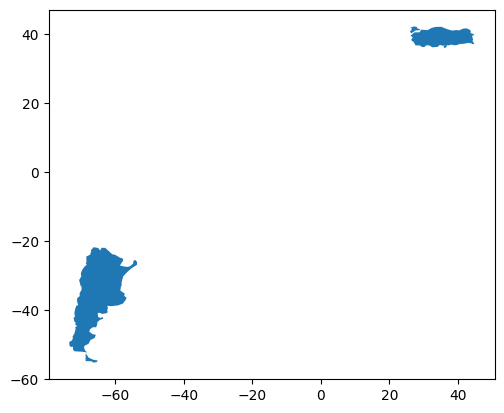

In [34]:
my_countries.plot()

In [38]:
turkey_news = pd.read_csv("../data/news/turkey_news.csv")
analyse_headline(turkey_news.iloc[0].to_dict())

SentimentResult(title='BRIEF - Turkey Discount Retailer Sok Marketler completes 2 . 3 bln lira IPO | Agricultural Commodities', sentiment='positive', key_phrase='completes 2.3 bln lira IPO', confidence='high', response_id='ZM0iao2BEdSB7M8PqePhkAU')

In [39]:
sample.shape

(900, 9)

In [40]:
sample = sample.sample(frac=1, random_state=42).reset_index(drop=True).head(480)
sample["country"].value_counts()

country
Argentina    253
Turkey       227
Name: count, dtype: int64

In [41]:
rows = sample.to_dict("records")
n = len(rows)

results_sentiment = []

for i, row in enumerate(rows, 1):
    result = with_retry(analyse_headline, row)
    results_sentiment.append(result)
    print(f"{i}/{n} — {result.sentiment}")
    time.sleep(4)

1/480 — negative
2/480 — negative
3/480 — negative
4/480 — positive
5/480 — neutral
6/480 — negative
7/480 — positive
8/480 — neutral
9/480 — negative
10/480 — positive
11/480 — neutral
12/480 — negative
13/480 — negative
14/480 — negative
15/480 — negative
16/480 — negative
17/480 — negative
18/480 — positive
19/480 — negative
20/480 — negative
21/480 — positive
22/480 — neutral
23/480 — negative
24/480 — positive
25/480 — negative
26/480 — negative
27/480 — neutral
28/480 — neutral
29/480 — positive
30/480 — positive
31/480 — negative
32/480 — negative
33/480 — neutral
34/480 — negative
35/480 — negative
36/480 — negative
37/480 — neutral
38/480 — neutral
39/480 — neutral
40/480 — negative
41/480 — positive
42/480 — negative
43/480 — negative
44/480 — positive
45/480 — neutral
46/480 — positive
47/480 — negative
48/480 — neutral
49/480 — positive
50/480 — negative
51/480 — neutral
52/480 — negative
53/480 — neutral
54/480 — positive
55/480 — negative
56/480 — neutral
57/480 — neutral

In [42]:
df_sentiment = pd.DataFrame([r.model_dump() for r in results_sentiment])
df_sentiment["country"] = sample["country"].values
df_sentiment.to_csv("../data/news/sentiment_results.csv", index=False)
df_sentiment.shape

(480, 6)

In [45]:
turkey_news = pd.read_csv("../data/news/turkey_news.csv")
argentina_news = pd.read_csv("../data/news/argentina_news.csv")
all_news = pd.concat([turkey_news, argentina_news], ignore_index=True)
news_dates = all_news[["title", "seendate"]]
news_dates.shape

(2956, 2)

In [55]:
df_sentiment = pd.read_csv("../data/news/sentiment_results.csv")
df_sentiment.shape

(480, 6)

In [56]:
news_dates_unique = news_dates.drop_duplicates(subset="title")
news_dates_unique.shape

(1773, 2)

In [57]:
df_sentiment = df_sentiment.merge(news_dates_unique, on="title", how="left")
df_sentiment.shape

(480, 7)

In [59]:
df_sentiment["date"] = pd.to_datetime(df_sentiment["seendate"], format="%Y%m%dT%H%M%SZ")
df_sentiment["date"].head()

0   2018-04-03 19:30:00
1   2018-06-08 14:00:00
2   2018-07-17 21:30:00
3   2018-11-01 12:45:00
4   2018-05-01 19:00:00
Name: date, dtype: datetime64[us]

In [61]:
df_sentiment["crisis_date"] = df_sentiment["country"].map({
    "Turkey": pd.Timestamp("2018-08-13"),
    "Argentina": pd.Timestamp("2018-05-01"),
})
df_sentiment["crisis_date"].head()

0   2018-05-01
1   2018-08-13
2   2018-05-01
3   2018-08-13
4   2018-05-01
Name: crisis_date, dtype: datetime64[us]

In [62]:
df_sentiment.columns.tolist()

['title',
 'sentiment',
 'key_phrase',
 'confidence',
 'response_id',
 'country',
 'seendate',
 'date',
 'crisis_date']

In [63]:
df_sentiment["period"] = "after"
df_sentiment.loc[df_sentiment["date"] < df_sentiment["crisis_date"], "period"] = "before"
df_sentiment["period"].value_counts()

period
after     246
before    234
Name: count, dtype: int64

In [64]:
df_sentiment.groupby(["country", "period"])["sentiment"].value_counts(normalize=True).round(3)

country    period  sentiment
Argentina  after   negative     0.480
                   positive     0.409
                   neutral      0.110
           before  negative     0.405
                   neutral      0.341
                   positive     0.254
Turkey     after   negative     0.563
                   positive     0.269
                   neutral      0.168
           before  negative     0.759
                   positive     0.204
                   neutral      0.037
Name: proportion, dtype: float64

In [65]:
df_sentiment["is_negative"] = (df_sentiment["sentiment"] == "negative").astype(int)
neg_rate = df_sentiment.groupby("country")["is_negative"].mean()
neg_rate

country
Argentina    0.442688
Turkey       0.656388
Name: is_negative, dtype: float64

In [66]:
neg_df = neg_rate.reset_index()
neg_df.columns = ["NAME", "neg_rate"]
neg_df

,NAME,neg_rate
0,Argentina,0.442688
1,Turkey,0.656388


In [67]:
my_countries = my_countries.merge(neg_df, on="NAME", how="left")
my_countries

,NAME,geometry,neg_rate
0,Argentina,"MULTIPOLYGON (((-68.63401 -52.63637, -68.25 -5...",0.442688
1,Turkey,"MULTIPOLYGON (((44.77268 37.17044, 44.29345 37...",0.656388


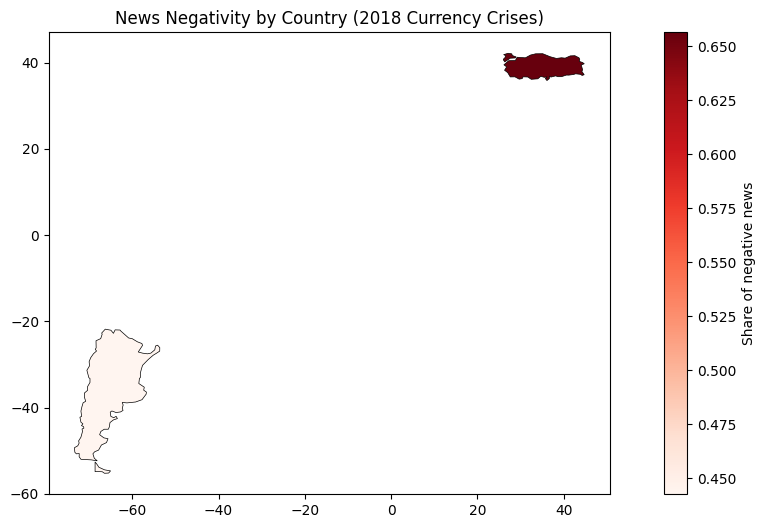

In [68]:
fig, ax = plt.subplots(figsize=(14, 6))
my_countries.plot(
    ax=ax,
    column="neg_rate",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"label": "Share of negative news"},
)
ax.set_title("News Negativity by Country (2018 Currency Crises)")
ax.set_aspect("equal")
plt.show()

In [69]:
period_neg = df_sentiment.groupby(["country", "period"])["is_negative"].mean()
period_neg

country    period
Argentina  after     0.480315
           before    0.404762
Turkey     after     0.563025
           before    0.759259
Name: is_negative, dtype: float64

In [70]:
period_table = period_neg.unstack()
period_table

period,after,before
country,,
Argentina,0.480315,0.404762
Turkey,0.563025,0.759259


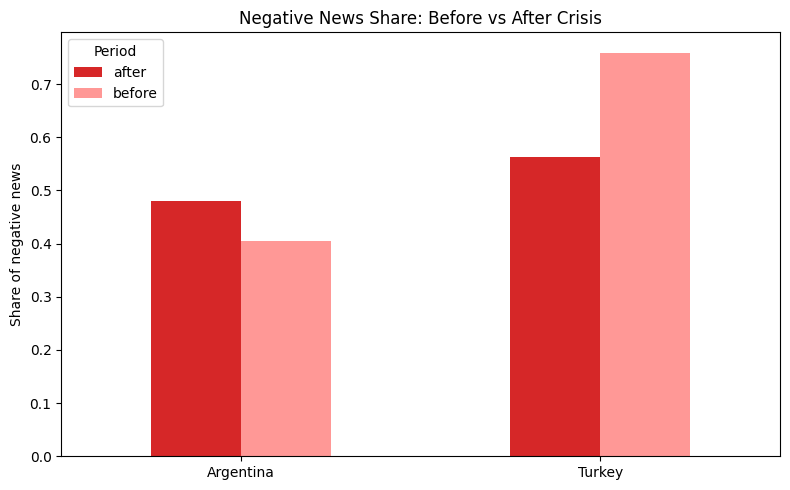

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))
period_table.plot(kind="bar", ax=ax, color=["#d62728", "#ff9896"])
ax.set_title("Negative News Share: Before vs After Crisis")
ax.set_ylabel("Share of negative news")
ax.set_xlabel("")
ax.legend(title="Period")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()